In [ ]:
import string
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import spacy
nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])

In [ ]:
df = pd.read_csv('df_total.csv')

TEXT_COL = "news"
CATEGORY_COL = "Type"

print(df.shape)
df.head()

**¿Cuántos documentos tiene el corpus?:** El corpus contiene 1,217 documentos.

**¿Qué columnas contiene y qué información guarda cada una?:** El corpus contiene 3 columnas en donde se guarda el url, texto de la noticia (news) y una etiqueta que hace referencia al tipo de noticia (type).

In [ ]:
# ¿Hay filas vacías o duplicadas?
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nFilas completamente duplicadas:", df.duplicated().sum())
print("Textos duplicados:", df.duplicated(subset=[TEXT_COL]).sum())

**¿Cuántas categorías hay y cómo se distribuyen?:** Existen 7 categorias unicas con la siguiente distribucion:
- Macroeconomia: 27.9%
- Alianzas: 20.3%
- Innovacion: 16.0%
- Regulaciones: 11.7%
- Sostenibilidad: 11.2%
- Otra: 10.7%
- Reputacion: 2.1%

In [ ]:
# ¿Hay filas vacías o duplicadas?
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nFilas completamente duplicadas:", df.duplicated().sum())
print("Textos duplicados:", df.duplicated(subset=[TEXT_COL]).sum())

**¿Hay filas vacías o duplicadas?:** Se identificaron 4 filas con valores nulos en la columna 'news'. Además, existen 75 filas completamente duplicadas y se encontraron 79 registros con contenido duplicado en la columna 'news'.

In [ ]:
df = df.dropna(subset=[TEXT_COL]).drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print("Shape final:", df.shape)

In [ ]:
from IPython.display import display

# Resumen del corpus que se utilizará en los modelos después de la limpieza
resumen_corpus_limpio = pd.DataFrame({
    'Cantidad': [
        len(df),
        df[CATEGORY_COL].nunique(),
        df[TEXT_COL].isna().sum(),
        df[TEXT_COL].duplicated().sum(),
    ]
}, index=[
    'Documentos',
    'Categorías',
    'Textos nulos',
    'Textos duplicados',
])

distribucion_corpus_limpio = df[CATEGORY_COL].value_counts().rename_axis('Categoría').to_frame('Documentos')
distribucion_corpus_limpio['Proporción'] = (
    distribucion_corpus_limpio['Documentos'] / len(df)
)

print('Resumen del corpus limpio:')
display(resumen_corpus_limpio)
print('Distribución de categorías del corpus limpio:')
display(distribucion_corpus_limpio)

---

In [ ]:
def contar_tokens_tipos(columna_de_listas):
    todos = [tok for lista in columna_de_listas for tok in lista]
    return len(todos), len(set(todos))

pasos = []

In [ ]:
# i. Tokenización
df['tokens'] = df[TEXT_COL].astype(str).apply(lambda x: word_tokenize(x, language='spanish'))
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Tokenización', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

In [ ]:
# ii. Minúsculas
df['tokens'] = df['tokens'].apply(lambda toks: [w.lower() for w in toks])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Minúsculas', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

In [ ]:
# iii. Eliminar puntuación
puntuacion = set(string.punctuation) | {'¿','¡','—','–','…','“','”','‘','’','»','«'}

def es_puntuacion(tok):
    return all(ch in puntuacion for ch in tok)

df['tokens'] = df['tokens'].apply(lambda toks: [w for w in toks if not es_puntuacion(w)])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Sin puntuación', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

In [ ]:
# iv. Eliminar stopwords
stop_es = set(stopwords.words('spanish'))
df['tokens'] = df['tokens'].apply(lambda toks: [w for w in toks if w not in stop_es])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Sin stopwords', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

In [ ]:
# v. Lematizar
textos_para_lematizar = df['tokens'].apply(lambda toks: ' '.join(toks))

lemas = []
for doc in nlp.pipe(textos_para_lematizar, batch_size=64):
    lemas.append([t.lemma_.lower() for t in doc if t.lemma_.strip() != ''])

df['tokens'] = lemas
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Lematizado', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

In [ ]:
# vi. Guardar el texto normalizado dentro del DataFrame
# Esta columna conserva la alineación por índice con el texto original y la categoría.
df['texto_normalizado'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))
corpus_normalizado = df['texto_normalizado']

columnas_corpus = [TEXT_COL, 'texto_normalizado', CATEGORY_COL]
assert all(columna in df.columns for columna in columnas_corpus)
assert df[columnas_corpus].notna().all().all()

df[columnas_corpus].head()

In [ ]:
pipeline = pd.DataFrame(pasos, columns=['Paso', 'Tokens', 'Tipos'])
pipeline['Tipo/Token'] = (pipeline['Tipos'] / pipeline['Tokens']).round(4)
pipeline

---

EDA del corpus

In [ ]:
# Tokens y tipos antes y después de la normalización

tokens_antes, tipos_antes = pasos[0][1], pasos[0][2]
tokens_despues, tipos_despues = pasos[-1][1], pasos[-1][2]

reduccion_vocab = (tipos_antes - tipos_despues) / tipos_antes * 100

print(f"Antes de normalizar   -> Tokens: {tokens_antes} | Tipos: {tipos_antes}")
print(f"Después de normalizar -> Tokens: {tokens_despues} | Tipos: {tipos_despues}")
print(f"Reducción del vocabulario: {reduccion_vocab:.1f}%")

In [ ]:
# Riqueza léxica

ttr_global = tipos_despues / tokens_despues
print(f"TTR global: {ttr_global:.4f}")

def ttr_por_categoria(df):
    resultados = {}
    for cat, grupo in df.groupby(CATEGORY_COL):
        todos = [tok for toks in grupo['tokens'] for tok in toks]
        resultados[cat] = len(set(todos)) / len(todos) if len(todos) > 0 else 0
    return pd.Series(resultados).sort_values(ascending=False)

ttr_categoria = ttr_por_categoria(df)
ttr_categoria

In [ ]:
# Top 20 palabras más frecuentes

all_tokens = [tok for toks in df['tokens'] for tok in toks]
frecuencias = Counter(all_tokens)

top20 = pd.DataFrame(frecuencias.most_common(20), columns=['Palabra', 'Frecuencia'])
top20

In [ ]:
# Histograma de tokens por documento

df['n_tokens'] = df['tokens'].apply(len)

plt.figure(figsize=(8,5))
plt.hist(df['n_tokens'], bins=40, edgecolor='white')
plt.xlabel('Tokens por documento')
plt.ylabel('Número de documentos')
plt.title('Distribución de tokens por documento (corpus normalizado)')
plt.tight_layout()
plt.show()

In [ ]:
# Ley de Zipf: corpus real vs. curva teórica

frecuencias_ordenadas = np.array([f for _, f in frecuencias.most_common()])
rangos = np.arange(1, len(frecuencias_ordenadas) + 1)

k = frecuencias_ordenadas[0]
zipf_teorica = k / rangos

plt.figure(figsize=(8,6))
plt.loglog(rangos, frecuencias_ordenadas, label='Corpus real')
plt.loglog(rangos, zipf_teorica, linestyle='--', label='Zipf teórica (k / rango)')
plt.xlabel('Rango (log)')
plt.ylabel('Frecuencia (log)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Comparación por categoría (top 10 palabras mas frecuentes)

categorias_a_comparar = ["Macroeconomia", "Innovacion"]
for cat in categorias_a_comparar:
    tokens_cat = [tok for toks in df[df[CATEGORY_COL] == cat]['tokens'] for tok in toks]
    top10_cat = Counter(tokens_cat).most_common(10)
    print(f"\nTop 10 — {cat}:")
    for palabra, freq in top10_cat:
        print(f"  {palabra}: {freq}")

In [ ]:
# Nube de palabras del vocabulario normalizado

from wordcloud import WordCloud

texto_completo = ' '.join(all_tokens)
wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate(texto_completo)

plt.figure(figsize=(12,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

---
---

## Laboratorio 2

#### 1. Bolsa de palabras (Bag of Words)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus_normalizado = df['tokens'].apply(lambda toks: ' '.join(toks))
vectorizer = CountVectorizer(lowercase=False)

X_bow = vectorizer.fit_transform(corpus_normalizado)

n_docs, vocab_size = X_bow.shape
print(f"Forma de la matriz BoW: {X_bow.shape}")
print(f"Número de documentos: {n_docs}")
print(f"Tamaño del vocabulario: {vocab_size}")

**Explique, con sus propias palabras, qué información se pierde al representar un documento como bolsa de palabras (orden, gramática, contexto) y qué se gana a cambio?**

Cuando se representa un documento como una bolsa de palabras, se tiende a perder el orden de las palabras, la gramática/estructura y el contexto en general de la información original. A cambio, se obtiene una representación numérica y se gana simplicidad y eficiencia para la construcción de modelos y la realización de cómputos rápidos.


---
#### 2. Vectores de conteo y dispersión 

In [ ]:
total_celdas = X_bow.shape[0] * X_bow.shape[1]

celdas_no_cero = X_bow.nnz
celdas_cero = total_celdas - celdas_no_cero

sparsity = celdas_cero / total_celdas * 100
print(f"Porcentaje de ceros (sparsity): {sparsity:.2f}%")

In [ ]:
vocab_sizes = [100, 500, 1000, 5000]
sparsities = []

for n in vocab_sizes:
    vec_temp = CountVectorizer(lowercase=False, max_features=n)
    X_temp = vec_temp.fit_transform(corpus_normalizado)
    total = X_temp.shape[0] * X_temp.shape[1]
    sparsity_temp = (total - X_temp.nnz) / total * 100
    sparsities.append(sparsity_temp)
    print(f"Vocabulario = {n} -> Sparsity: {sparsity_temp:.2f}%")

plt.figure(figsize=(8,5))
plt.plot(vocab_sizes, sparsities, marker='o')
plt.xlabel('Tamaño del vocabulario (max_features)')
plt.ylabel('Dispersión (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **¿Por qué crece la dispersión al aumentar el vocabulario? ¿Qué implicaciones tiene esto en el costo de almacenamiento y de cómputo?**: La dispercion crece porque cada ves que se aumenta el vocabulario porque se incorporan cada vez palabras mas raras que aparecen en pocos documentos. Esto genera una matriz con cada vez más valores cero, aumentando el espacio de almacenamiento necesario y haciendo que los cálculos sean más costosos y lentos.

- **¿Qué es una matriz dispersa (sparse matrix)? ¿Por qué se usan estructuras especiales (p. ej. formato CSR) en vez de matrices densas para este tipo de datos?**: Una matriz dispersa es una matriz donde la mayoria de los elementos son cero. Se utilizan estructuras especiales, como la del formato CSR, porque permiten almacenar unicamente los valores que son diferentes a 0 y sus pocisiones. Esto permite reducir el espacio de almacenamiento necesario y hacer calculos mas eficientes.

---
#### 3. N-gramas

In [ ]:
# Unigramas
vectorizer_uni = CountVectorizer(lowercase=False, ngram_range=(1, 1))
X_uni = vectorizer_uni.fit_transform(corpus_normalizado)

# Bigramas
vectorizer_bi = CountVectorizer(lowercase=False, ngram_range=(2, 2))
X_bi = vectorizer_bi.fit_transform(corpus_normalizado)

print(f"Vocabulario unigramas: {X_uni.shape[1]}")
print(f"Vocabulario bigramas:  {X_bi.shape[1]}")

In [ ]:
frecuencias_bi = np.asarray(X_bi.sum(axis=0)).flatten()
vocab_bi = vectorizer_bi.get_feature_names_out()

top_idx = np.argsort(frecuencias_bi)[::-1][:15]
top_bigramas = pd.DataFrame({
    'Bigrama': vocab_bi[top_idx],
    'Frecuencia': frecuencias_bi[top_idx]
})

top_bigramas

- **¿Los bigramas aportan informacion que los unigramas (por si solos) no capturan?**: Algunos bigramas (como los de 'banco central', 'tasa interés', 'cambio climatica') si ofrecen mas informacion ya que capturan de mejor manera algunas relaciones semanticas que los unigramas pierden por ambiguedad.

- **¿Qué ventaja ofrecen los bigramas/trigramas frente a la bolsa de palabras clásica (unigramas)? ¿Qué costo tienen en tamaño de vocabulario?**: Los bigramas/trigramas caputran relaciones de contexto local y ayudan a reducir la ambiguedad que algunos terminos pierden al estar sueltas. El costo es un crecimiento rapido del tamaño de vocabulario, lo que lleva a una mayor dispercion en la matriz y un mayor costo de almacenamiento y computo.

---
#### 4. TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(lowercase=False)
X_tfidf = tfidf_vectorizer.fit_transform(corpus_normalizado)

print(f"Shape TF-IDF: {X_tfidf.shape}")

In [ ]:
categorias_unicas = df[CATEGORY_COL].unique()

cats_elegidas = ["Macroeconomia", "Alianzas", "Innovacion"]
docs_idx = [df[df[CATEGORY_COL] == cat].index[0] for cat in cats_elegidas]

vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Top 10 palabras con mayor puntaje TF-IDF")
for idx, cat in zip(docs_idx, cats_elegidas):
    fila_tfidf = X_tfidf[idx].toarray().flatten()
    top10_idx = np.argsort(fila_tfidf)[::-1][:10]
    
    print(f"\nDocumento {idx} ({cat})")
    for i in top10_idx:
        print(f"- {vocab_tfidf[i]}: {fila_tfidf[i]:.4f}")

**¿Qué valor juegan estas palabras dentro de los artículos y como refleja su puntaje este papel?**

Estas palabras funcionan como etiquetas que ayudan a identificar de qué trata cada artículo. El puntaje refleja qué tan frecuente es una palabra dentro del documento y qué tan común es en relación con el resto del corpus. Mientras más alto sea el puntaje, más exclusiva y representativa es esa palabra de ese artículo en particular.

In [ ]:
vocab_bow = vectorizer.get_feature_names_out()

print("Top 10 palabras mas frecuentes (conteo simple)")
for idx, cat in zip(docs_idx, cats_elegidas):
    fila_conteo = X_bow[idx].toarray().flatten()
    top10_idx = np.argsort(fila_conteo)[::-1][:10]
    
    print(f"\nDocumento {idx} ({cat})")
    for i in top10_idx:
        print(f"- {vocab_bow[i]}: {fila_conteo[i]}")

**¿Las 10 palabras con mayor puntaje TF-IDF coinciden con las 10 palabras más frecuentes (por conteo simple) de los mismos documentos? ¿Qué diferencias observa y por qué ocurren, según las fórmulas de TF e IDF vistas en clase?**

No coinciden completamente. Aunque algunas palabras aparecen en ambas listas, otras palabras tienen un puntaje TF-IDF alto aunque no sean las más frecuentes. Esto pasas porque el TF considera qué tan frecuente es una palabra dentro del documento, mientras que el IDF reduce el peso de las palabras que aparecen en muchos documentos del corpus.

**¿Por que es que TF-IDF penaliza palabras muy comunes en todo el corpus y favorece palabras raras pero repetidas dentro de un documento?**

TF-IDF penaliza las palabras comunes porque su valor IDF disminuye cuando una palabra aparece en muchos documentos. Una palabra que aparece varias veces en un documento pero en pocos documentos del corpus tiende a obtener un valor TF alto y un valor IDF alto.

---
#### 5. Similitud entre documentos (similitud coseno)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(X_tfidf)
print(f"Shape matriz de similitud: {sim_matrix.shape}")

In [ ]:
doc_ref_idx = 0
# doc_ref_idx = 3

cat_ref = df.loc[doc_ref_idx, CATEGORY_COL]

similitudes = sim_matrix[doc_ref_idx]

similitudes_sin_self = similitudes.copy()
similitudes_sin_self[doc_ref_idx] = -1

top5_idx = np.argsort(similitudes_sin_self)[::-1][:5]

print(f"Documento {doc_ref_idx} ({cat_ref})\n")

print("Documentos más similares:")
for i in top5_idx:
    print(f"- Doc {i} | Categoría: {df.loc[i, CATEGORY_COL]} | Similitud: {similitudes_sin_self[i]:.4f}")

coincidencias = sum(df.loc[i, CATEGORY_COL] == cat_ref for i in top5_idx)
print(f"\nCoincidencias de categoría: {coincidencias}/5")

In [ ]:
cats_unicas = sorted(df[CATEGORY_COL].unique())
sim_por_categoria = pd.DataFrame(index=cats_unicas, columns=cats_unicas, dtype=float)

for c1 in cats_unicas:
    for c2 in cats_unicas:
        idx1 = df[df[CATEGORY_COL] == c1].index.values
        idx2 = df[df[CATEGORY_COL] == c2].index.values
        bloque = sim_matrix[np.ix_(idx1, idx2)]
        if c1 == c2:
            mask = ~np.eye(bloque.shape[0], dtype=bool)
            sim_por_categoria.loc[c1, c2] = bloque[mask].mean()
        else:
            sim_por_categoria.loc[c1, c2] = bloque.mean()

sim_por_categoria

**Explique ¿por qué se usa similitud coseno en lugar de distancia euclidiana para comparar documentos de distinta longitud?**

Se usa la similitud coseno porque mide el ángulo entre los vectores en vez de su magnitud. Esto significa que compara la proporción relativa de palabras sin verse afectada por la longitud del documento a diferencia de lla distancia euclidiana, que sí depende de la magnitud y por lo tanto termina penalizando a documentos largos aunque traten el mismo tema que uno corto.

---
---

## Laboratorio 3

#### 1. Conjuntos de entrenamiento, validación y prueba

In [ ]:
from sklearn.model_selection import train_test_split

X = corpus_normalizado
y = df[CATEGORY_COL]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Número de documentos por conjunto:")
print(f"- Entrenamiento: {len(y_train)}")
print(f"- Validación:    {len(y_val)}")
print(f"- Prueba:        {len(y_test)}")
print(f"- Total:         {len(y_train) + len(y_val) + len(y_test)}")

In [ ]:
conteos = pd.DataFrame({
    'Entrenamiento': y_train.value_counts(),
    'Validación': y_val.value_counts(),
    'Prueba': y_test.value_counts(),
}).fillna(0).astype(int)

conteos

In [ ]:
proporciones = pd.DataFrame({
    'Entrenamiento': y_train.value_counts(normalize=True),
    'Validación': y_val.value_counts(normalize=True),
    'Prueba': y_test.value_counts(normalize=True),
}).fillna(0).round(4)

proporciones

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (nombre, etiquetas) in zip(
    axes,
    [('Entrenamiento', y_train), ('Validación', y_val), ('Prueba', y_test)]
):
    etiquetas.value_counts().plot(kind='bar', ax=ax, title=nombre)
    ax.set_ylabel('Número de documentos')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Explique con sus propias palabras para qué sirve cada conjunto (entrenamiento, validación, prueba) y por qué no se debe usar el conjunto de prueba para tomar decisiones durante el desarrollo del modelo.**

Los conjuntos de entrenamiento, validación y prueba tienen diferentes objetivos. El conjunto de entrenamiento se utiliza para que el modelo pueda aprender los patrones presentes en el corpus. Por otro lado, el conjunto de validación se utiliza para comparar modelos, ajustar hiperparámetros o decidir cuándo detener el entrenamiento, por ejemplo, para evitar el sobreajuste. Por último, el conjunto de prueba se utiliza únicamente para medir qué tan bien generaliza el modelo cuando se le presentan datos que nunca ha visto. Este conjunto no debe utilizarse para tomar decisiones durante el desarrollo del modelo, ya que esto haría que dejara de ser una medida confiable de su capacidad de generalización. En ese caso, terminaría funcionando como un segundo conjunto de validación, sobre el cual también podría producirse un sobreajuste de manera involuntaria.

---

#### 2. Construcción del clasificador Naive Bayes

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

bow_vectorizer = CountVectorizer(lowercase=False)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)
X_test_bow = bow_vectorizer.transform(X_test)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

print("Modelo Naive Bayes (Bolsa de Palabras) entrenado.")
print(f"  Vocabulario: {len(bow_vectorizer.get_feature_names_out())} palabras")
print(f"  Categorías: {list(nb_bow.classes_)}")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_train = TfidfVectorizer(lowercase=False)
X_train_tfidf = tfidf_vectorizer_train.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer_train.transform(X_val)
X_test_tfidf = tfidf_vectorizer_train.transform(X_test)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

print("Modelo Naive Bayes (TF-IDF) entrenado.")
print(f"  Vocabulario: {len(tfidf_vectorizer_train.get_feature_names_out())} palabras")
print(f"  Categorías: {list(nb_tfidf.classes_)}")

**Explique, con sus propias palabras y apoyándose en el teorema de Bayes visto en clase, qué representan P(c) y P(wᵢ|c) en el contexto de este corpus de noticias, y cómo el modelo combina ambas probabilidades para clasificar un documento nuevo.**

P(c) es la probabilidad a priori de una categoría. Basicamente es qué tan frecuente es esa categoría dentro del conjunto de entrenamiento, sin tomar en cuenta el contenido del documento. P(wᵢ|c), por otro lado, es la probabilidad de observar una palabra específica (wᵢ) dado que el documento pertenece a la categoría c, se estima a partir de qué tan seguido aparece esa palabra en los documentos de entrenamiento de esa categoría en particular. Para clasificar un documento nuevo, el modelo aplica el teorema de Bayes en donde P(c|documento) es proporcional a P(c) multiplicado por el producto de P(wᵢ|c) de todas las palabras del documento. Combina qué tan probable es la categoría de antemano con qué tan probable es observar cada una de las palabras del documento si se asume que pertenece a esa categoría, asumiendo que las palabras son independientes entre sí. Este cálculo se repite para cada categoría posible, y el modelo asigna al documento la categoría que obtiene la probabilidad más alta.

---

#### 3. Entrenamiento y evaluación

In [ ]:
from sklearn.metrics import classification_report

y_val_pred_bow = nb_bow.predict(X_val_bow)
y_val_pred_tfidf = nb_tfidf.predict(X_val_tfidf)

print("Reporte de clasificación — BoW (validación)")
print(classification_report(y_val, y_val_pred_bow, zero_division=0))

print("Reporte de clasificación — TF-IDF (validación)")
print(classification_report(y_val, y_val_pred_tfidf, zero_division=0))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

categorias_orden = sorted(y.unique())

cm_bow = confusion_matrix(y_val, y_val_pred_bow, labels=categorias_orden)
cm_tfidf = confusion_matrix(y_val, y_val_pred_tfidf, labels=categorias_orden)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias_orden, yticklabels=categorias_orden, ax=axes[0])
axes[0].set_title('Matriz de confusión — BoW (validación)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias_orden, yticklabels=categorias_orden, ax=axes[1])
axes[1].set_title('Matriz de confusión — TF-IDF (validación)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

y_train_pred_bow = nb_bow.predict(X_train_bow)
y_train_pred_tfidf = nb_tfidf.predict(X_train_tfidf)

comparacion = pd.DataFrame({
    'Modelo': ['BoW', 'BoW', 'TF-IDF', 'TF-IDF'],
    'Conjunto': ['Entrenamiento', 'Validación', 'Entrenamiento', 'Validación'],
    'Accuracy': [
        accuracy_score(y_train, y_train_pred_bow),
        accuracy_score(y_val, y_val_pred_bow),
        accuracy_score(y_train, y_train_pred_tfidf),
        accuracy_score(y_val, y_val_pred_tfidf),
    ],
    'F1 macro': [
        f1_score(y_train, y_train_pred_bow, average='macro'),
        f1_score(y_val, y_val_pred_bow, average='macro'),
        f1_score(y_train, y_train_pred_tfidf, average='macro'),
        f1_score(y_val, y_val_pred_tfidf, average='macro'),
    ],
})

comparacion

In [ ]:
y_test_pred_bow = nb_bow.predict(X_test_bow)
y_test_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

print("Reporte de clasificación — BoW (prueba)")
print(classification_report(y_test, y_test_pred_bow, zero_division=0))

print("Reporte de clasificación — TF-IDF (prueba)")
print(classification_report(y_test, y_test_pred_tfidf, zero_division=0))

In [ ]:
cm_bow_test = confusion_matrix(y_test, y_test_pred_bow, labels=categorias_orden)
cm_tfidf_test = confusion_matrix(y_test, y_test_pred_tfidf, labels=categorias_orden)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_bow_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias_orden, yticklabels=categorias_orden, ax=axes[0])
axes[0].set_title('Matriz de confusión — BoW (prueba)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_tfidf_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias_orden, yticklabels=categorias_orden, ax=axes[1])
axes[1].set_title('Matriz de confusión — TF-IDF (prueba)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Compare el desempeño en entrenamiento contra el desempeño en validación/prueba. ¿Hay indicios de overfitting? Relacione su respuesta con lo visto en clase sobre generalización.**

En entrenamiento, el modelo BoW obtuvo un accuracy de 0.96 y el de TF-IDF de 0.70, mientras que en validación bajaron a 0.81 y 0.53 respectivamente. Esta misma tendencia se mantiene en prueba, con un accuracy de 0.81 para BoW y 0.54 para TF-IDF. En el caso de BoW, sí hay indicios de overfitting, ya que pasa de un F1 de 0.95 en entrenamiento a 0.75 en validación, lo que significa que el modelo está memorizando en vez de aprender únicamente patrones que generalicen. Sin embargo, como sus resultados en validación y prueba son bastante similares, el sobreajuste no parece ser tan severo y el modelo todavía logra generalizar de manera razonable.

El modelo TF-IDF presenta un comportamiento diferente. Su accuracy en entrenamiento ya es más bajo que el de BoW, y en validación y prueba disminuye todavía más, hasta 0.53 y 0.54. Esto no parece ser un caso típico de overfitting, ya que el modelo tampoco obtiene un buen desempeño en entrenamiento. Más bien, los resultados sugieren que esta combinación de TF-IDF con MultinomialNB no funcionó bien para este corpus, ya que el modelo terminó favoreciendo principalmente a la categoría "Macroeconomia". Esto se puede observar en el reporte de clasificación, donde esta categoría tiene un recall de 1.00, mientras que otras como "Otra", "Regulaciones", "Reputacion" y "Sostenibilidad" obtienen precision y recall de 0.00 en prueba.


**Indique cuál de los dos modelos (BoW o TF-IDF) obtuvo mejor desempeño y proponga una explicación, en términos de cómo cada representación pondera las palabras.**

En cuanto al desempeño general, BoW fue el mejor modelo, ya que obtuvo valores más altos de accuracy y F1 macro en entrenamiento, validación y prueba. BoW representa directamente la frecuencia de aparición de las palabras, lo cual se adapta mejor a MultinomialNB. TF-IDF, en cambio, transforma estas frecuencias en valores ponderados que reducen la importancia de las palabras que aparecen en muchos documentos. En este corpus, algunas de esas palabras pueden seguir siendo útiles para distinguir entre categorías, por lo que reducir su peso termina afectando el desempeño del modelo. Por esta razón, BoW resultó ser la representación más adecuada para este caso.

---

### 4. Análisis de errores

In [ ]:
mejor_nb = nb_bow
mejor_vectorizer = bow_vectorizer
y_true_analisis = y_test
y_pred_analisis = y_test_pred_bow
X_textos_analisis = X_test

cm_mejor = confusion_matrix(y_true_analisis, y_pred_analisis, labels=categorias_orden)
cm_sin_diag = cm_mejor.copy()
np.fill_diagonal(cm_sin_diag, 0)

i, j = np.unravel_index(np.argmax(cm_sin_diag), cm_sin_diag.shape)
cat_real, cat_pred = categorias_orden[i], categorias_orden[j]

print("Categorías más confundidas entre sí:")
print(f"  Real: '{cat_real}' -> Predicho: '{cat_pred}'  ({cm_sin_diag[i, j]} documentos)")
print(f"  Real: '{cat_pred}' -> Predicho: '{cat_real}'  ({cm_sin_diag[j, i]} documentos)")
print(f"  Total de confusiones cruzadas: {cm_sin_diag[i, j] + cm_sin_diag[j, i]}")

**Revise 3 a 5 documentos mal clasificados de esas categorías y comente qué palabras pudieron llevar al modelo a equivocarse.**

Las categorías que más se confunden entre sí son "Otra" y "Sostenibilidad". El modelo clasificó 4 documentos que realmente eran "Otra" como si fueran "Sostenibilidad", mientras que en sentido contrario no hubo ningún error. Al revisar estos 4 documentos, todos tratan sobre BBVA y contienen varias palabras relacionadas con sostenibilidad, como "sostenible", "sostenibilidad" o "energía", aunque el tema principal del artículo sea otro. Esto explica el error, ya que palabras como "agua" tienen una probabilidad mucho mayor bajo "Sostenibilidad" que bajo "Otra" (0.002670 frente a 0.000076), y lo mismo ocurre con "energía" (0.005106 frente a 0.000279) y "objetivo" (0.002508 frente a 0.000786). Aunque también aparecen palabras más relacionadas con "Otra", como "bbva", "banco" y "millón", la acumulación de varias palabras asociadas con sostenibilidad termina haciendo que el modelo favorezca esa categoría.

In [ ]:
def palabras_sospechosas(texto_norm, cat_verdadera, cat_predicha, top_n=10):
    X_doc = mejor_vectorizer.transform([texto_norm])
    vocab = mejor_vectorizer.get_feature_names_out()

    idx_verdadera = np.where(mejor_nb.classes_ == cat_verdadera)[0][0]
    idx_predicha = np.where(mejor_nb.classes_ == cat_predicha)[0][0]

    cols = X_doc.nonzero()[1]
    candidatas = []
    for col in cols:
        cuenta = X_doc[0, col]
        p_verdadera = np.exp(mejor_nb.feature_log_prob_[idx_verdadera, col])
        p_predicha = np.exp(mejor_nb.feature_log_prob_[idx_predicha, col])
        candidatas.append((vocab[col], cuenta, p_verdadera, p_predicha))

    candidatas.sort(key=lambda x: x[3] * x[1], reverse=True)
    return candidatas[:top_n]

mask_err = (y_true_analisis == cat_real) & (y_pred_analisis == cat_pred)
indices_err = y_true_analisis[mask_err].index[:5]

print(f"Documentos mal clasificados: '{cat_real}' -> '{cat_pred}'\n")

for n, idx in enumerate(indices_err, 1):
    texto_norm = X_textos_analisis.loc[idx]

    print(f"--- Documento {n} (índice {idx}) ---")
    print(f"Texto original (extracto): {df.loc[idx, TEXT_COL][:300]}...")
    print(f"Texto normalizado (extracto): {texto_norm[:300]}...")

    sospechosas = palabras_sospechosas(texto_norm, cat_real, cat_pred)
    print("Palabras que pudieron influir en la predicción incorrecta:")
    for palabra, cuenta, p_real, p_pred in sospechosas:
        print(f"  - {palabra} (freq={cuenta}, P(w|{cat_real})={p_real:.6f}, P(w|{cat_pred})={p_pred:.6f})")
    print()

**Calcule y liste las palabras con mayor P(wᵢ|c) (verosimilitud) para dos o tres categorías del corpus. ¿Tienen sentido como palabras representativas de esa categoría?**

Para "Sostenibilidad", las palabras con mayor P(w|c) fueron "energía", "sostenible", "eléctrico", "sostenibilidad", "agua", "objetivo" y "cambio". Estas tienen sentido como palabras representativas porque están directamente relacionadas con temas ambientales y de sostenibilidad corporativa. Para "Macroeconomia", las palabras principales fueron "inflación", "precio", "tasa", "crecimiento", "económico" y "aumento", que también son términos esperables en noticias de esta categoría. Sin embargo, en ambas categorías y también en "Otra" aparecen palabras más generales como "bbva", "año", "poder", "hacer", "ser" y "él", que no son realmente distintivas.

In [ ]:
def top_verosimilitud(modelo, vectorizer, categoria, n=15):
    idx = np.where(modelo.classes_ == categoria)[0][0]
    vocab = vectorizer.get_feature_names_out()
    log_probs = modelo.feature_log_prob_[idx]

    top_idx = np.argsort(log_probs)[::-1][:n]
    return pd.DataFrame({
        'Palabra': vocab[top_idx],
        'P(w|c)': np.exp(log_probs[top_idx]).round(6)
    })

cats_verosimilitud = list(dict.fromkeys([cat_real, cat_pred, 'Macroeconomia']))

for cat in cats_verosimilitud:
    print(f"\nTop palabras con mayor P(w|c) — categoría '{cat}':")
    print(top_verosimilitud(mejor_nb, mejor_vectorizer, cat).to_string(index=False))

**Relacione los errores encontrados con el supuesto de independencia condicional de Naive Bayes: ¿en qué casos cree que este supuesto "ingenuo" contribuyó a una clasificación incorrecta?**

Naive Bayes asume que cada palabra de un documento es independiente de las demás y utiliza la evidencia de cada una para calcular la probabilidad de cada categoría. En los 4 documentos de "Otra" que fueron clasificados como "Sostenibilidad", este supuesto pudo contribuir directamente al error, porque el modelo no puede considerar el contexto en el que aparecen las palabras. Por ejemplo, no puede distinguir entre un artículo que trata principalmente sobre sostenibilidad y uno que habla de un tema financiero pero menciona varias veces conceptos relacionados con sostenibilidad. El modelo únicamente observa palabras como "sostenible", "sostenibilidad", "agua", "energía" y "objetivo", y como varias de ellas tienen una alta probabilidad bajo "Sostenibilidad", la evidencia se va acumulando a favor de esa categoría.

---

### 5. Efecto de la representación de texto

In [ ]:
import time

resultados_max_features = []

for n_features in [1000, 5000]:
    vectorizer_mf = CountVectorizer(lowercase=False, max_features=n_features)

    inicio = time.time()
    X_train_mf = vectorizer_mf.fit_transform(X_train)
    X_val_mf = vectorizer_mf.transform(X_val)

    nb_mf = MultinomialNB()
    nb_mf.fit(X_train_mf, y_train)
    tiempo_mf = time.time() - inicio

    y_val_pred_mf = nb_mf.predict(X_val_mf)

    resultados_max_features.append({
        'Representación': f'BoW (max_features={n_features})',
        'Vocabulario': len(vectorizer_mf.get_feature_names_out()),
        'Accuracy': accuracy_score(y_val, y_val_pred_mf),
        'F1 macro': f1_score(y_val, y_val_pred_mf, average='macro'),
        'Tiempo (s)': round(tiempo_mf, 4)
    })

pd.DataFrame(resultados_max_features)

In [ ]:
resultados_ngramas = []

for nombre, ngram_range in [('Solo unigramas', (1, 1)), ('Unigramas + bigramas', (1, 2))]:
    vectorizer_ng = CountVectorizer(lowercase=False, ngram_range=ngram_range)

    inicio = time.time()
    X_train_ng = vectorizer_ng.fit_transform(X_train)
    X_val_ng = vectorizer_ng.transform(X_val)

    nb_ng = MultinomialNB()
    nb_ng.fit(X_train_ng, y_train)
    tiempo_ng = time.time() - inicio

    y_val_pred_ng = nb_ng.predict(X_val_ng)

    resultados_ngramas.append({
        'Representación': f'BoW ({nombre})',
        'Vocabulario': len(vectorizer_ng.get_feature_names_out()),
        'Accuracy': accuracy_score(y_val, y_val_pred_ng),
        'F1 macro': f1_score(y_val, y_val_pred_ng, average='macro'),
        'Tiempo (s)': round(tiempo_ng, 4)
    })

pd.DataFrame(resultados_ngramas)

**¿Mejora el desempeño respecto al modelo de solo unigramas? ¿A qué costo, en tamaño de vocabulario y tiempo de entrenamiento?**

Agregar bigramas no mejoró el desempeño; al contrario, el accuracy bajó de 0.81 con solo unigramas a 0.77, mientras que el F1 macro disminuyó de 0.75 a 0.66. Además, el costo de utilizar bigramas fue considerable. El vocabulario aumentó de 19,039 a 183,394 términos, lo que representa casi 10 veces más términos, y el tiempo de entrenamiento pasó de 0.17 s a 0.78 s, por lo que el modelo tardó más de 4 veces en entrenarse.

Esto puede explicarse por el tamaño del corpus, ya que con solo unos cientos de documentos de entrenamiento muchos de los bigramas aparecen muy pocas veces. En lugar de aportar información útil para distinguir entre categorías, estos términos agregan más dispersión y generan muchas características que aparecen en pocos documentos. Esto dificulta que el modelo pueda estimar probabilidades confiables y puede afectar su capacidad de generalización. Tambien, Naive Bayes sigue tratando cada característica como evidencia independiente, por lo que agregar bigramas no significa que el modelo pueda comprender mejor el contexto de las palabras. En este caso, el aumento del vocabulario y del tiempo de entrenamiento no produjo ninguna mejora, sino que terminó reduciendo el desempeño del modelo.

In [ ]:
class NaiveBayesMultinomial:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.clases_ = np.unique(y)
        n_clases = len(self.clases_)
        n_features = X.shape[1]

        self.log_prior_ = np.zeros(n_clases)
        self.log_likelihood_ = np.zeros((n_clases, n_features))

        for idx, clase in enumerate(self.clases_):
            X_clase = X[(y == clase).values]

            self.log_prior_[idx] = np.log(X_clase.shape[0] / X.shape[0])

            conteo_palabras = np.asarray(X_clase.sum(axis=0)).flatten()
            total_palabras = conteo_palabras.sum()

            self.log_likelihood_[idx] = np.log(
                (conteo_palabras + self.alpha) / (total_palabras + self.alpha * n_features)
            )

        return self

    def predict(self, X):
        log_posterior = X @ self.log_likelihood_.T + self.log_prior_
        indices_predichos = np.argmax(log_posterior, axis=1)
        return self.clases_[indices_predichos]

In [ ]:
nb_propio = NaiveBayesMultinomial(alpha=1.0)
nb_propio.fit(X_train_bow, y_train)

y_val_pred_propio = nb_propio.predict(X_val_bow)

accuracy_propio = accuracy_score(y_val, y_val_pred_propio)
f1_propio = f1_score(y_val, y_val_pred_propio, average='macro')

print(f"Accuracy (implementación propia): {accuracy_propio:.4f}")
print(f"F1 macro (implementación propia): {f1_propio:.4f}")

print(f"\nAccuracy (sklearn MultinomialNB): {accuracy_score(y_val, y_val_pred_bow):.4f}")
print(f"F1 macro (sklearn MultinomialNB): {f1_score(y_val, y_val_pred_bow, average='macro'):.4f}")

In [ ]:
tabla_comparativa = pd.DataFrame([
    {
        'Representación': 'BoW (vocabulario completo)',
        'Vocabulario': len(bow_vectorizer.get_feature_names_out()),
        'Accuracy': accuracy_score(y_val, y_val_pred_bow),
        'F1 macro': f1_score(y_val, y_val_pred_bow, average='macro'),
    },
    {
        'Representación': 'TF-IDF (vocabulario completo)',
        'Vocabulario': len(tfidf_vectorizer_train.get_feature_names_out()),
        'Accuracy': accuracy_score(y_val, y_val_pred_tfidf),
        'F1 macro': f1_score(y_val, y_val_pred_tfidf, average='macro'),
    },
] + resultados_max_features + resultados_ngramas)

tabla_comparativa.loc[len(tabla_comparativa)] = {
    'Representación': 'Implementación propia (BoW)',
    'Vocabulario': len(bow_vectorizer.get_feature_names_out()),
    'Accuracy': accuracy_propio,
    'F1 macro': f1_propio,
}

tabla_comparativa

---
---

## Laboratorio 4

### 1. Construcción del clasificador de regresión logística

In [59]:
from time import perf_counter
from sklearn.linear_model import LogisticRegression

configuracion_lr = {
    'C': 1.0,
    'solver': 'lbfgs',
    'max_iter': 3000,
}

inicio = perf_counter()

lr_bow = LogisticRegression(**configuracion_lr)
lr_bow.fit(X_train_bow, y_train)

tiempo_lr_bow = perf_counter() - inicio

inicio = perf_counter()

lr_tfidf = LogisticRegression(**configuracion_lr)
lr_tfidf.fit(X_train_tfidf, y_train)

tiempo_lr_tfidf = perf_counter() - inicio


print("Modelo de regresión logística (BoW) entrenado.")
print(f"  Vocabulario: {len(bow_vectorizer.get_feature_names_out())} palabras")
print(f"  Categorías: {list(lr_bow.classes_)}")
print(f"  Tiempo de entrenamiento: {tiempo_lr_bow:.4f} segundos")

print("\nModelo de regresión logística (TF-IDF) entrenado.")
print(f"  Vocabulario: {len(tfidf_vectorizer_train.get_feature_names_out())} palabras")
print(f"  Categorías: {list(lr_tfidf.classes_)}")
print(f"  Tiempo de entrenamiento: {tiempo_lr_tfidf:.4f} segundos")


resumen_entrenamiento_lr = pd.DataFrame([
    {
        'Modelo': 'Regresión logística',
        'Representación': 'BoW',
        'Vocabulario': len(bow_vectorizer.get_feature_names_out()),
        'Categorías': len(lr_bow.classes_),
        'C': lr_bow.C,
        'Iteraciones': int(lr_bow.n_iter_.max()),
        'Tiempo (s)': round(tiempo_lr_bow, 4),
    },
    {
        'Modelo': 'Regresión logística',
        'Representación': 'TF-IDF',
        'Vocabulario': len(tfidf_vectorizer_train.get_feature_names_out()),
        'Categorías': len(lr_tfidf.classes_),
        'C': lr_tfidf.C,
        'Iteraciones': int(lr_tfidf.n_iter_.max()),
        'Tiempo (s)': round(tiempo_lr_tfidf, 4),
    },
])

resumen_entrenamiento_lr

Modelo de regresión logística (BoW) entrenado.
  Vocabulario: 19039 palabras
  Categorías: ['Alianzas', 'Innovacion', 'Macroeconomia', 'Otra', 'Regulaciones', 'Reputacion', 'Sostenibilidad']
  Tiempo de entrenamiento: 0.6770 segundos

Modelo de regresión logística (TF-IDF) entrenado.
  Vocabulario: 19039 palabras
  Categorías: ['Alianzas', 'Innovacion', 'Macroeconomia', 'Otra', 'Regulaciones', 'Reputacion', 'Sostenibilidad']
  Tiempo de entrenamiento: 0.4172 segundos


,Modelo,Representación,Vocabulario,Categorías,C,Iteraciones,Tiempo (s)
0,Regresión logística,BoW,19039,7,1.0,53,0.6770
1,Regresión logística,TF-IDF,19039,7,1.0,32,0.4172


**Explique con sus propias palabras qué representan z = w·x + b y la función sigmoide σ(z) = 1/(1+e⁻ᶻ) en este contexto, y cómo se convierte ese puntaje en una probabilidad y luego en una predicción de clase.**

En este contexto, x representa un documento convertido en un vector BoW o TF-IDF, w contiene los pesos aprendidos para las palabras y b es el sesgo; por lo tanto, z=w⋅x+b es el puntaje que indica cuánta evidencia existe a favor de una categoría. La función sigmoide transforma ese puntaje en un valor entre 0 y 1 que puede interpretarse como una probabilidad en un problema de dos clases. Como este corpus tiene siete categorías, el modelo calcula un puntaje para cada una, los convierte en probabilidades mediante la función softmax y predice la categoría que obtiene la probabilidad más alta.

---

### 2. Entrenamiento y evaluación

In [ ]:
y_train_pred_lr_bow = lr_bow.predict(X_train_bow)
y_train_pred_lr_tfidf = lr_tfidf.predict(X_train_tfidf)


print("Reporte de clasificación — Regresión logística + BoW (entrenamiento)")
print(
    classification_report(
        y_train,
        y_train_pred_lr_bow,
        digits=4,
        zero_division=0
    )
)

print("Reporte de clasificación — Regresión logística + TF-IDF (entrenamiento)")
print(
    classification_report(
        y_train,
        y_train_pred_lr_tfidf,
        digits=4,
        zero_division=0
    )
)

Reporte de clasificación — Regresión logística + BoW (entrenamiento)
                precision    recall  f1-score   support

      Alianzas     1.0000    1.0000    1.0000       172
    Innovacion     1.0000    1.0000    1.0000       106
 Macroeconomia     1.0000    1.0000    1.0000       223
          Otra     1.0000    1.0000    1.0000        90
  Regulaciones     1.0000    1.0000    1.0000        99
    Reputacion     1.0000    1.0000    1.0000        18
Sostenibilidad     1.0000    1.0000    1.0000        87

      accuracy                         1.0000       795
     macro avg     1.0000    1.0000    1.0000       795
  weighted avg     1.0000    1.0000    1.0000       795

Reporte de clasificación — Regresión logística + TF-IDF (entrenamiento)
                precision    recall  f1-score   support

      Alianzas     0.9448    0.9942    0.9688       172
    Innovacion     0.9381    1.0000    0.9680       106
 Macroeconomia     0.9651    0.9910    0.9779       223
          Otra 

In [ ]:
y_val_pred_lr_bow = lr_bow.predict(X_val_bow)
y_val_pred_lr_tfidf = lr_tfidf.predict(X_val_tfidf)


print("Reporte de clasificación — Regresión logística + BoW (validación)")
print(
    classification_report(
        y_val,
        y_val_pred_lr_bow,
        digits=4,
        zero_division=0
    )
)

print("Reporte de clasificación — Regresión logística + TF-IDF (validación)")
print(
    classification_report(
        y_val,
        y_val_pred_lr_tfidf,
        digits=4,
        zero_division=0
    )
)

Reporte de clasificación — Regresión logística + BoW (validación)
                precision    recall  f1-score   support

      Alianzas     0.8222    1.0000    0.9024        37
    Innovacion     0.8519    1.0000    0.9200        23
 Macroeconomia     0.9111    0.8542    0.8817        48
          Otra     0.8750    0.7368    0.8000        19
  Regulaciones     0.9444    0.8095    0.8718        21
    Reputacion     1.0000    0.5000    0.6667         4
Sostenibilidad     0.9444    0.8947    0.9189        19

      accuracy                         0.8830       171
     macro avg     0.9070    0.8279    0.8516       171
  weighted avg     0.8898    0.8830    0.8802       171

Reporte de clasificación — Regresión logística + TF-IDF (validación)
                precision    recall  f1-score   support

      Alianzas     0.7500    0.9730    0.8471        37
    Innovacion     0.8214    1.0000    0.9020        23
 Macroeconomia     0.8600    0.8958    0.8776        48
          Otra     0.

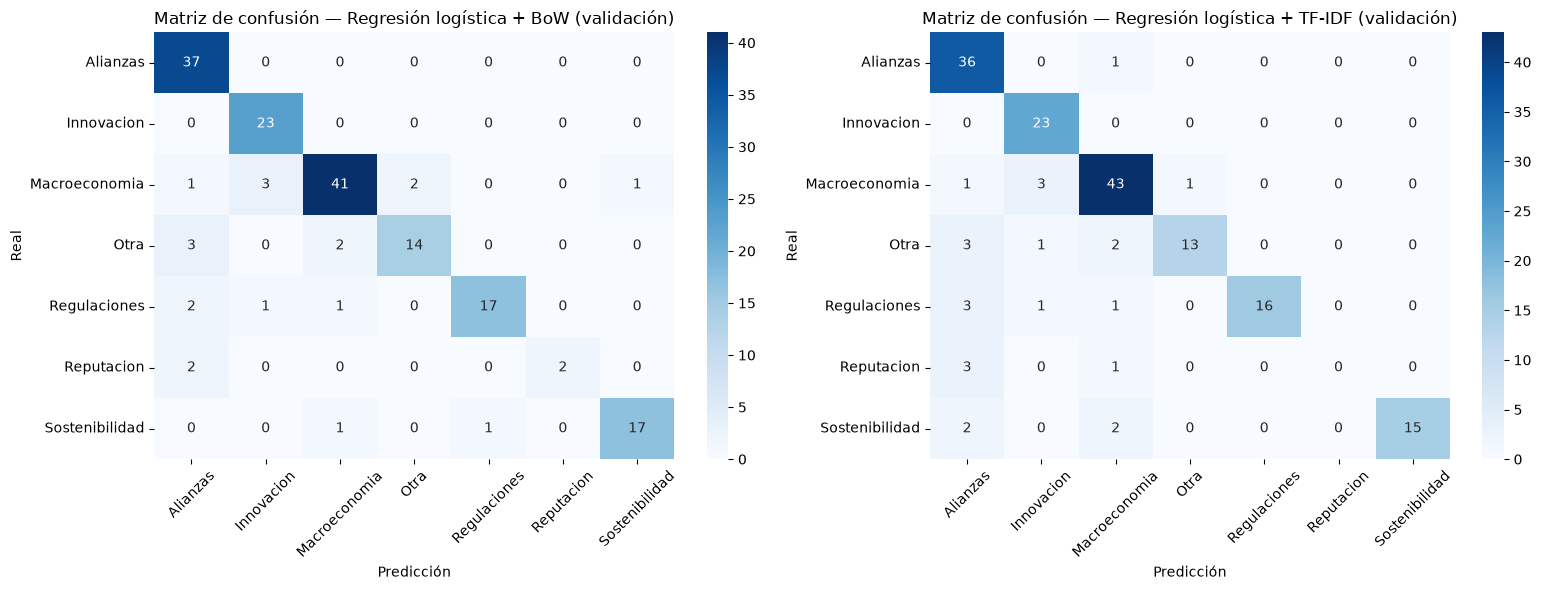

In [ ]:
categorias_orden_lr = list(lr_bow.classes_)

cm_lr_bow_val = confusion_matrix(
    y_val,
    y_val_pred_lr_bow,
    labels=categorias_orden_lr
)

cm_lr_tfidf_val = confusion_matrix(
    y_val,
    y_val_pred_lr_tfidf,
    labels=categorias_orden_lr
)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_lr_bow_val,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=categorias_orden_lr,
    yticklabels=categorias_orden_lr,
    ax=axes[0]
)

axes[0].set_title('Matriz de confusión — Regresión logística + BoW (validación)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)


sns.heatmap(
    cm_lr_tfidf_val,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=categorias_orden_lr,
    yticklabels=categorias_orden_lr,
    ax=axes[1]
)

axes[1].set_title('Matriz de confusión — Regresión logística + TF-IDF (validación)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
y_test_pred_lr_bow = lr_bow.predict(X_test_bow)
y_test_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)


print("Reporte de clasificación — Regresión logística + BoW (prueba)")
print(
    classification_report(
        y_test,
        y_test_pred_lr_bow,
        digits=4,
        zero_division=0
    )
)

print("Reporte de clasificación — Regresión logística + TF-IDF (prueba)")
print(
    classification_report(
        y_test,
        y_test_pred_lr_tfidf,
        digits=4,
        zero_division=0
    )
)

Reporte de clasificación — Regresión logística + BoW (prueba)
                precision    recall  f1-score   support

      Alianzas     0.8947    0.9189    0.9067        37
    Innovacion     0.9500    0.8261    0.8837        23
 Macroeconomia     0.9362    0.9167    0.9263        48
          Otra     0.7895    0.7500    0.7692        20
  Regulaciones     0.9474    0.8571    0.9000        21
    Reputacion     1.0000    0.7500    0.8571         4
Sostenibilidad     0.6400    0.8889    0.7442        18

      accuracy                         0.8713       171
     macro avg     0.8797    0.8440    0.8553       171
  weighted avg     0.8836    0.8713    0.8739       171

Reporte de clasificación — Regresión logística + TF-IDF (prueba)
                precision    recall  f1-score   support

      Alianzas     0.6538    0.9189    0.7640        37
    Innovacion     0.8077    0.9130    0.8571        23
 Macroeconomia     0.9362    0.9167    0.9263        48
          Otra     0.8333    

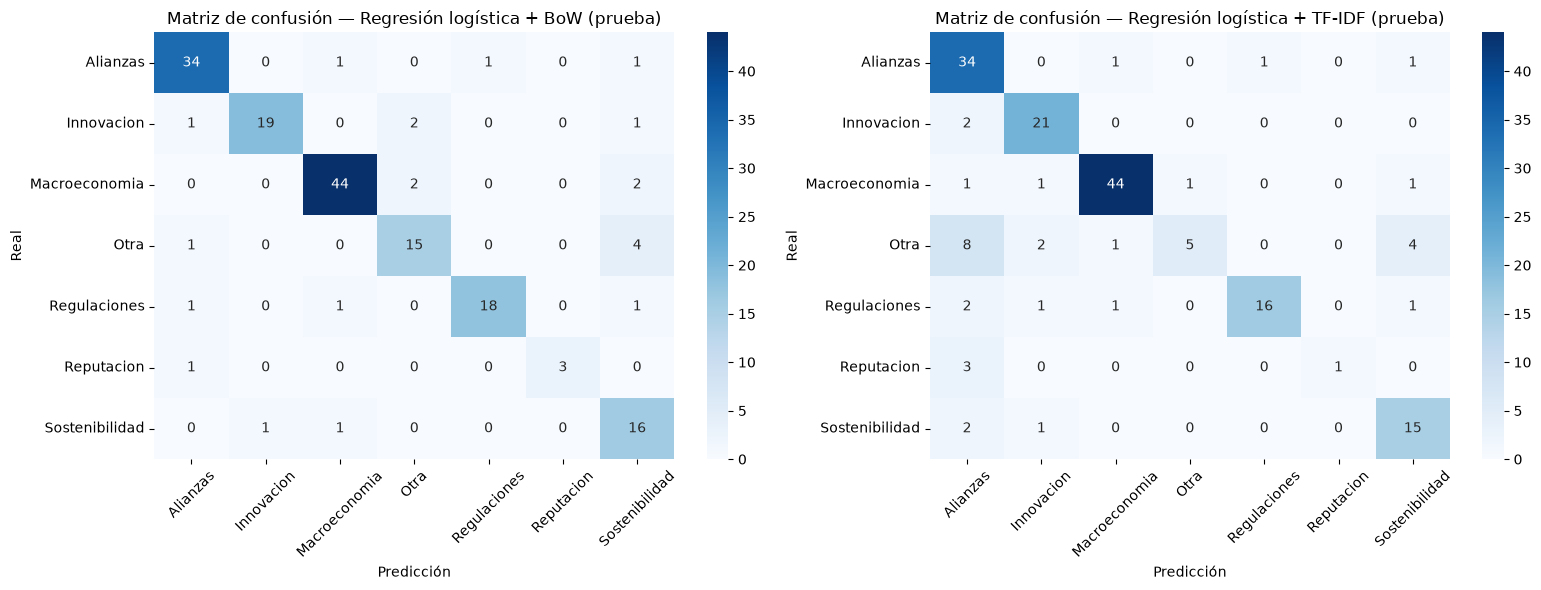

In [ ]:
cm_lr_bow_test = confusion_matrix(
    y_test,
    y_test_pred_lr_bow,
    labels=categorias_orden_lr
)

cm_lr_tfidf_test = confusion_matrix(
    y_test,
    y_test_pred_lr_tfidf,
    labels=categorias_orden_lr
)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_lr_bow_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=categorias_orden_lr,
    yticklabels=categorias_orden_lr,
    ax=axes[0]
)

axes[0].set_title('Matriz de confusión — Regresión logística + BoW (prueba)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)


sns.heatmap(
    cm_lr_tfidf_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=categorias_orden_lr,
    yticklabels=categorias_orden_lr,
    ax=axes[1]
)

axes[1].set_title('Matriz de confusión — Regresión logística + TF-IDF (prueba)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
evaluaciones_lr = [
    (
        'Regresión logística + BoW',
        'Entrenamiento',
        y_train,
        y_train_pred_lr_bow
    ),
    (
        'Regresión logística + TF-IDF',
        'Entrenamiento',
        y_train,
        y_train_pred_lr_tfidf
    ),
    (
        'Regresión logística + BoW',
        'Validación',
        y_val,
        y_val_pred_lr_bow
    ),
    (
        'Regresión logística + TF-IDF',
        'Validación',
        y_val,
        y_val_pred_lr_tfidf
    ),
    (
        'Regresión logística + BoW',
        'Prueba',
        y_test,
        y_test_pred_lr_bow
    ),
    (
        'Regresión logística + TF-IDF',
        'Prueba',
        y_test,
        y_test_pred_lr_tfidf
    ),
]


resultados_lr = []

for nombre_modelo, conjunto, y_real, y_pred in evaluaciones_lr:

    reporte = classification_report(
        y_real,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    resultados_lr.append({
        'Modelo': nombre_modelo,
        'Conjunto': conjunto,
        'Accuracy': reporte['accuracy'],
        'Precision macro': reporte['macro avg']['precision'],
        'Recall macro': reporte['macro avg']['recall'],
        'F1 macro': reporte['macro avg']['f1-score'],
        'Precision ponderada': reporte['weighted avg']['precision'],
        'Recall ponderado': reporte['weighted avg']['recall'],
        'F1 ponderado': reporte['weighted avg']['f1-score'],
    })


tabla_metricas_lr = pd.DataFrame(resultados_lr)

tabla_metricas_lr.round(4)

,Modelo,Conjunto,Accuracy,Precision macro,Recall macro,F1 macro,Precision ponderada,Recall ponderado,F1 ponderado
0,Regresión logística + BoW,Entrenamiento,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Regresión logística + TF-IDF,Entrenamiento,0.9648,0.9734,0.8951,0.9185,0.9660,0.9648,0.9625
2,Regresión logística + BoW,Validación,0.8830,0.9070,0.8279,0.8516,0.8898,0.8830,0.8802
3,Regresión logística + TF-IDF,Validación,0.8538,0.7657,0.7292,0.7374,0.8513,0.8538,0.8427
4,Regresión logística + BoW,Prueba,0.8713,0.8797,0.8440,0.8553,0.8836,0.8713,0.8739
5,Regresión logística + TF-IDF,Prueba,0.7953,0.8363,0.6920,0.7035,0.8211,0.7953,0.7773


**Compare el desempeño en entrenamiento contra el desempeño en validación/prueba. ¿Hay indicios de overfitting? Relacione su respuesta con lo visto en clase sobre generalización.**

Ambos modelos presentan indicios de overfitting, ya que sus resultados de entrenamiento son superiores a los de validación y prueba. En BoW, el accuracy disminuye de 1.0000 en entrenamiento a 0.8830 en validación y 0.8713 en prueba; sin embargo, la pequeña diferencia entre validación y prueba indica que, aunque el modelo aprendió muy bien los datos de entrenamiento, mantiene una generalización relativamente estable sobre documentos nuevos. En TF-IDF, el accuracy baja de 0.9648 a 0.8538 y finalmente a 0.7953, junto con una caída importante del F1 macro de 0.9185 a 0.7035, por lo que muestra una generalización más débil y mayores indicios de overfitting.

**Indique cuál de las dos representaciones (BoW o TF-IDF) obtuvo mejor desempeño con regresión logística y proponga una explicación**

La representación BoW obtuvo el mejor desempeño con regresión logística, tanto en validación como en prueba. En prueba alcanzó un accuracy de 0.8713, un F1 macro de 0.8553 y un F1 ponderado de 0.8739, mientras que TF-IDF obtuvo 0.7953, 0.7035 y 0.7773, respectivamente. Una posible explicación es que los conteos de BoW conservaron la frecuencia de palabras que se repiten y que resultan útiles para diferenciar las categorías del corpus, mientras que TF-IDF redujo el peso de algunos términos frecuentes que todavía podían aportar información discriminativa; además, su menor F1 macro sugiere que tuvo más dificultades para clasificar de manera equilibrada las categorías con menos ejemplos.

---

### 3. Interpretación de pesos

In [74]:
mejor_lr = lr_bow
mejor_vectorizer_lr = bow_vectorizer
nb_comparacion = nb_bow

categorias_pesos = [
    'Otra',
    'Sostenibilidad',
    'Macroeconomia',
]

vocabulario = mejor_vectorizer_lr.get_feature_names_out()


def comparar_pesos_categoria(modelo_lr, modelo_nb, vocabulario, categoria, n=15):

    indice_lr = np.where(modelo_lr.classes_ == categoria)[0][0]
    indice_nb = np.where(modelo_nb.classes_ == categoria)[0][0]

    coeficientes = modelo_lr.coef_[indice_lr]

    log_verosimilitudes = modelo_nb.feature_log_prob_[indice_nb]

    indices_positivos = np.where(coeficientes > 0)[0]
    indices_negativos = np.where(coeficientes < 0)[0]

    top_positivos = indices_positivos[
        np.argsort(coeficientes[indices_positivos])[::-1][:n]
    ]

    top_negativos = indices_negativos[
        np.argsort(coeficientes[indices_negativos])[:n]
    ]

    top_nb = np.argsort(log_verosimilitudes)[::-1][:n]

    palabras_positivas = vocabulario[top_positivos]
    palabras_negativas = vocabulario[top_negativos]
    palabras_nb = vocabulario[top_nb]

    tabla = pd.DataFrame({
        'Palabra a favor (LR)': palabras_positivas,
        'Peso positivo': coeficientes[top_positivos].round(4),
        'Palabra en contra (LR)': palabras_negativas,
        'Peso negativo': coeficientes[top_negativos].round(4),
        'Mayor P(w|c) (NB)': palabras_nb,
        'P(w|c)': np.exp(log_verosimilitudes[top_nb]).round(6),
    })

    conjunto_nb = set(palabras_nb)

    coincidencias_positivas = [
        palabra
        for palabra in palabras_positivas
        if palabra in conjunto_nb
    ]

    coincidencias_negativas = [
        palabra
        for palabra in palabras_negativas
        if palabra in conjunto_nb
    ]

    return tabla, coincidencias_positivas, coincidencias_negativas

assert mejor_lr.coef_.shape[1] == len(vocabulario)
assert nb_comparacion.feature_log_prob_.shape[1] == len(vocabulario)


resumen_coincidencias = []

for categoria in categorias_pesos:

    tabla, coincidencias_pos, coincidencias_neg = comparar_pesos_categoria(
        modelo_lr=mejor_lr,
        modelo_nb=nb_comparacion,
        vocabulario=vocabulario,
        categoria=categoria,
        n=15
    )

    print("=" * 100)
    print(f"Categoría: {categoria}")
    print("=" * 100)

    display(tabla)

    resumen_coincidencias.append({
        'Categoría': categoria,
        'Coincidencias positivas LR / NB': len(coincidencias_pos),
        'Porcentaje de coincidencia': len(coincidencias_pos) / 15,
        'Palabras positivas coincidentes':
            ', '.join(coincidencias_pos)
            if coincidencias_pos else 'Ninguna',
        'Palabras negativas coincidentes con NB':
            ', '.join(coincidencias_neg)
            if coincidencias_neg else 'Ninguna',
    })

tabla_coincidencias = pd.DataFrame(resumen_coincidencias)
tabla_coincidencias['Porcentaje de coincidencia'] = (
    tabla_coincidencias['Porcentaje de coincidencia'] * 100
).round(2)

display(tabla_coincidencias)

Categoría: Otra


,Palabra a favor (LR),Peso positivo,Palabra en contra (LR),Peso negativo,Mayor P(w|c) (NB),P(w|c)
0,bbva,0.3470,alianza,-0.2455,bbva,0.006791
1,colombia,0.2822,él,-0.1948,banco,0.006208
2,entidad,0.2592,empresa,-0.1643,millón,0.004941
3,el,0.2549,seguro,-0.1626,año,0.003978
4,asegurar,0.2386,2022,-0.1572,entidad,0.003649
5,frente,0.2226,tecnología,-0.1528,financiero,0.003623
6,carrera,0.2160,comercio,-0.1506,crédito,0.003167
7,interés,0.2153,permitir,-0.1470,poder,0.002965
8,gasto,0.2110,innovación,-0.1440,cliente,0.002737
9,hacer,0.2106,podcast,-0.1332,tasa,0.002610


Categoría: Sostenibilidad


,Palabra a favor (LR),Peso positivo,Palabra en contra (LR),Peso negativo,Mayor P(w|c) (NB),P(w|c)
0,sostenible,0.5162,colombia,-0.2112,bbva,0.005648
1,podcast,0.3691,la,-0.2104,energía,0.005106
2,yo,0.2859,el,-0.1679,sostenible,0.004944
3,climático,0.2705,en,-0.1480,él,0.004709
4,acompaña,0.2681,presidente,-0.1361,poder,0.004637
5,ir,0.2525,área,-0.1307,año,0.003104
6,futuro,0.2405,mercado,-0.1306,eléctrico,0.002743
7,renovable,0.2328,reto,-0.1203,ser,0.002707
8,natural,0.2321,servicio,-0.1151,sostenibilidad,0.002670
9,bbva,0.2295,pago,-0.1147,agua,0.002670


Categoría: Macroeconomia


,Palabra a favor (LR),Peso positivo,Palabra en contra (LR),Peso negativo,Mayor P(w|c) (NB),P(w|c)
0,inflación,0.4768,usuario,-0.2160,inflación,0.010695
1,precio,0.2856,digital,-0.2111,precio,0.008001
2,aumento,0.2812,persona,-0.2090,año,0.007944
3,año,0.2404,empresa,-0.2032,poder,0.005753
4,seguro,0.2356,alianza,-0.1898,bbva,0.004383
5,ipc,0.2330,colombia,-0.1875,él,0.004200
6,economista,0.2273,frente,-0.1730,mayor,0.004189
7,research,0.2260,financiero,-0.1712,mes,0.003995
8,2023,0.2195,millón,-0.1670,tasa,0.003709
9,economía,0.2180,compañía,-0.1664,país,0.003675


,Categoría,Coincidencias positivas LR / NB,Porcentaje de coincidencia,Palabras positivas coincidentes,Palabras negativas coincidentes con NB
0,Otra,5,33.33,"bbva, colombia, entidad, hacer, crédito",Ninguna
1,Sostenibilidad,2,13.33,"sostenible, bbva",Ninguna
2,Macroeconomia,6,40.00,"inflación, precio, aumento, año, bbva, crecimi...",Ninguna


**¿Tienen sentido esas palabras como evidencia a favor o en contra de cada categoría?**

En general, sí tienen sentido; por ejemplo, en Macroeconomía aparecen términos claramente relacionados, como inflación, precio, IPC, economía y crecimiento, mientras que en Sostenibilidad destacan sostenible, climático, renovable, natural y responsable. En la categoría Otra, las palabras son menos específicas porque reúne documentos que no encajan claramente en las demás clases.

**Compare estas palabras con las de mayor P(wᵢ|c) (verosimilitud) obtenidas con Naive Bayes en el Laboratorio #3 para las mismas categorías. ¿Coinciden en su mayoría? ¿Qué diferencias encuentra y a qué las atribuye?**

Las palabras no coinciden en su mayoría, solo coincidieron 5 de 15 en Otra, 2 de 15 en Sostenibilidad y 6 de 15 en Macroeconomía. Naive Bayes destaca palabras frecuentes dentro de una categoría, aunque también sean comunes en otras. La regresión logística aprende todos los pesos conjuntamente y favorece las palabras que mejor diferencian una categoría de las demás. Por eso existen coincidencias en términos muy representativos como inflación, precio, crecimiento y sostenible, pero también diferencias que se pueden dar por la forma distinta en que ambos modelos calculan la importancia de cada palabra.

---

### 4. Comparación con Naive Bayes

In [75]:
from sklearn.base import clone

def medir_tiempo_entrenamiento(modelo, X_entrenamiento, y_entrenamiento, repeticiones=5):
    tiempos = []

    for _ in range(repeticiones):
        modelo_temporal = clone(modelo)

        inicio = perf_counter()
        modelo_temporal.fit(X_entrenamiento, y_entrenamiento)
        tiempo = perf_counter() - inicio

        tiempos.append(tiempo)

    return float(np.median(tiempos))


modelos_comparacion = [
    {
        'Modelo': 'Naive Bayes',
        'Representación': 'BoW',
        'Estimador': nb_bow,
        'X entrenamiento': X_train_bow,
        'X prueba': X_test_bow,
    },
    {
        'Modelo': 'Naive Bayes',
        'Representación': 'TF-IDF',
        'Estimador': nb_tfidf,
        'X entrenamiento': X_train_tfidf,
        'X prueba': X_test_tfidf,
    },
    {
        'Modelo': 'Regresión logística',
        'Representación': 'BoW',
        'Estimador': lr_bow,
        'X entrenamiento': X_train_bow,
        'X prueba': X_test_bow,
    },
    {
        'Modelo': 'Regresión logística',
        'Representación': 'TF-IDF',
        'Estimador': lr_tfidf,
        'X entrenamiento': X_train_tfidf,
        'X prueba': X_test_tfidf,
    },
]


resultados_comparacion = []

for configuracion in modelos_comparacion:

    modelo = configuracion['Estimador']
    X_entrenamiento = configuracion['X entrenamiento']
    X_prueba = configuracion['X prueba']

    y_pred = modelo.predict(X_prueba)

    reporte = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    tiempo_aproximado = medir_tiempo_entrenamiento(
        modelo,
        X_entrenamiento,
        y_train,
        repeticiones=5
    )

    resultados_comparacion.append({
        'Modelo': configuracion['Modelo'],
        'Representación': configuracion['Representación'],
        'Accuracy': reporte['accuracy'],
        'F1 macro': reporte['macro avg']['f1-score'],
        'F1 ponderado': reporte['weighted avg']['f1-score'],
        'Tiempo entrenamiento (s)': tiempo_aproximado,
    })


tabla_comparacion_modelos = pd.DataFrame(resultados_comparacion)

display(
    tabla_comparacion_modelos.round({
        'Accuracy': 4,
        'F1 macro': 4,
        'F1 ponderado': 4,
        'Tiempo entrenamiento (s)': 6,
    })
)

,Modelo,Representación,Accuracy,F1 macro,F1 ponderado,Tiempo entrenamiento (s)
0,Naive Bayes,BoW,0.8129,0.7370,0.8028,0.005280
1,Naive Bayes,TF-IDF,0.5439,0.3049,0.4349,0.004560
2,Regresión logística,BoW,0.8713,0.8553,0.8739,0.686434
3,Regresión logística,TF-IDF,0.7953,0.7035,0.7773,0.445689


**¿Qué modelo obtuvo mejor desempeño en general sobre el conjunto de prueba? ¿La diferencia es grande o marginal?**

El mejor modelo fue la regresión logística con BoW, con un accuracy de 0.8713, un F1 macro de 0.8553 y un F1 ponderado de 0.8739. En comparación, el segundo mejor fue Naive Bayes con BoW, con 0.8129, 0.7370 y 0.8028. Sin embargo, Naive Bayes fue mucho más rápido: aproximadamente 0.005 segundos, frente a 0.686 segundos de regresión logística, aunque en términos absolutos ambos tiempos siguen siendo bajos para este corpus.

**Relacione la diferencia (o similitud) de desempeño con la forma en que cada modelo calcula sus pesos: estimación aislada de P(wᵢ|c) bajo independencia condicional en Naive Bayes, frente a optimización conjunta de todos los pesos en regresión logística.**

La diferencia de desempeño puede explicarse por la forma en que cada modelo aprende la importancia de las palabras. Naive Bayes estima cada P(wᵢ∣c) por separado y supone independencia condicional, por lo que puede dar importancia a términos frecuentes aunque también aparezcan en otras categorías. La regresión logística optimiza conjuntamente todos los pesos para encontrar las características que mejor separan las clases. Esto probablemente permitió que la regresión logística obtuviera mejores métricas con BoW y TF-IDF, aunque a cambio necesitó más tiempo de entrenamiento que Naive Bayes.

---

### 5. Análisis de errores

In [79]:
mejor_lr = lr_bow
mejor_vectorizer_lr = bow_vectorizer

y_pred_lr_analisis = lr_bow.predict(X_test_bow)
categorias_orden_lr = list(lr_bow.classes_)

cm_lr_analisis = confusion_matrix(
    y_test,
    y_pred_lr_analisis,
    labels=categorias_orden_lr
)

mejor_total = -1
cat_a = None
cat_b = None

for i in range(len(categorias_orden_lr)):
    for j in range(i + 1, len(categorias_orden_lr)):

        total_confusiones = (
            cm_lr_analisis[i, j] +
            cm_lr_analisis[j, i]
        )

        if total_confusiones > mejor_total:
            mejor_total = total_confusiones
            cat_a = categorias_orden_lr[i]
            cat_b = categorias_orden_lr[j]
            conf_a_b = cm_lr_analisis[i, j]
            conf_b_a = cm_lr_analisis[j, i]


print("Categorías más confundidas entre sí:")
print(f"  Real: '{cat_a}' -> Predicho: '{cat_b}' ({conf_a_b} documentos)")
print(f"  Real: '{cat_b}' -> Predicho: '{cat_a}' ({conf_b_a} documentos)")
print(f"  Total de confusiones cruzadas: {mejor_total}")

Categorías más confundidas entre sí:
  Real: 'Otra' -> Predicho: 'Sostenibilidad' (4 documentos)
  Real: 'Sostenibilidad' -> Predicho: 'Otra' (0 documentos)
  Total de confusiones cruzadas: 4


In [80]:
vocabulario_lr = bow_vectorizer.get_feature_names_out()


def palabras_error_lr(texto_norm, categoria_real, categoria_predicha, top_n=10):
    X_doc = bow_vectorizer.transform([texto_norm])

    idx_real = np.where(lr_bow.classes_ == categoria_real)[0][0]
    idx_pred = np.where(lr_bow.classes_ == categoria_predicha)[0][0]

    pesos_real = lr_bow.coef_[idx_real]
    pesos_pred = lr_bow.coef_[idx_pred]

    columnas = X_doc.nonzero()[1]

    resultados = []

    for col in columnas:

        frecuencia = X_doc[0, col]

        peso_real = pesos_real[col]
        peso_pred = pesos_pred[col]

        diferencia = (peso_pred - peso_real) * frecuencia

        resultados.append({
            'Palabra': vocabulario_lr[col],
            'Frecuencia': int(frecuencia),
            f'Peso {categoria_real}': peso_real,
            f'Peso {categoria_predicha}': peso_pred,
            'Ventaja clase predicha': diferencia,
        })

    tabla = pd.DataFrame(resultados)

    return (
        tabla
        .sort_values('Ventaja clase predicha', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [81]:
mask_errores_lr = (
    ((y_test == cat_a) & (y_pred_lr_analisis == cat_b)) |
    ((y_test == cat_b) & (y_pred_lr_analisis == cat_a))
)

indices_errores_lr = y_test[mask_errores_lr].index[:5]

print(f"Documentos seleccionados para analizar: {len(indices_errores_lr)}")


for numero, idx in enumerate(indices_errores_lr, 1):

    categoria_real = y_test.loc[idx]
    categoria_predicha = y_pred_lr_analisis[
        list(y_test.index).index(idx)
    ]

    texto_norm = X_test.loc[idx]

    print("\n" + "=" * 100)
    print(f"Documento {numero} — índice {idx}")
    print(f"Categoría real: {categoria_real}")
    print(f"Predicción LR: {categoria_predicha}")
    print("=" * 100)

    print(f"\nTexto original (extracto):\n{df.loc[idx, TEXT_COL][:500]}...")

    print("\nPalabras que más favorecieron la predicción incorrecta:")

    display(
        palabras_error_lr(
            texto_norm,
            categoria_real,
            categoria_predicha,
            top_n=10
        ).round(4)
    )

Documentos seleccionados para analizar: 4

Documento 1 — índice 988
Categoría real: Otra
Predicción LR: Sostenibilidad

Texto original (extracto):
Bbva ha actuado como banco coordinador en la financiación en formato project finance por US3799 millones 320 millones de euros  de Nabiax empresa de data centers en España y América Latina esta operación marca un hito en el sector de la tecnología de datos.Este project finance se convierte en sostenible al vincular el mecanismo de precio a tres indicadores ESG dos de ellos medioambientales relacionados con las emisiones de carbono y el tratamiento del agua y uno social de igualdad de género. Los...

Palabras que más favorecieron la predicción incorrecta:


,Palabra,Frecuencia,Peso Otra,Peso Sostenibilidad,Ventaja clase predicha
0,sostenible,2,0.1651,0.5162,0.7023
1,objetivo,3,-0.0700,0.1194,0.5681
2,renovable,2,-0.0470,0.2328,0.5595
3,agua,3,-0.0313,0.0901,0.3643
4,climático,1,-0.0659,0.2705,0.3364
5,consumo,3,0.0355,0.1355,0.2999
6,empresa,2,-0.1643,-0.0518,0.2250
7,cambio,2,-0.0126,0.0932,0.2115
8,carbono,1,-0.0669,0.1327,0.1996
9,compromiso,3,-0.0020,0.0612,0.1896



Documento 2 — índice 426
Categoría real: Otra
Predicción LR: Sostenibilidad

Texto original (extracto):
Bbva ascendió una posición en el Dow Jones Sustainability Index Djsi y se convirtió en el banco más sostenible del mundo junto a la entidad surcoreana KB Financial Group. Ambos obtuvieron la máxima puntuación dentro de la categoría de bancos a nivel global.La entidad financiera que tenía 88 puntos de un máximo posible de 100 logró 89 puntos después de que SP volviera a evaluar la respuesta aportada por el banco. Bbva ya había logrado la máxima puntuación en inclusión financiera información medio...

Palabras que más favorecieron la predicción incorrecta:


,Palabra,Frecuencia,Peso Otra,Peso Sostenibilidad,Ventaja clase predicha
0,sostenible,3,0.1651,0.5162,1.0534
1,objetivo,4,-0.0700,0.1194,0.7575
2,global,3,-0.0199,0.0989,0.3565
3,climático,1,-0.0659,0.2705,0.3364
4,responsable,1,-0.0253,0.2266,0.2518
5,máximo,4,-0.0204,0.0423,0.2506
6,financiero,3,0.0205,0.1028,0.2467
7,futuro,1,0.0331,0.2405,0.2074
8,él,1,-0.1948,0.0086,0.2034
9,carbono,1,-0.0669,0.1327,0.1996



Documento 3 — índice 696
Categoría real: Otra
Predicción LR: Sostenibilidad

Texto original (extracto):
En el marco del Foro de La banca articuladora empresarial para el desarrollo sostenible organizado por este medio Antoni Ballabriga director de negocio responsable de Bbva dijo que los ODS y los acuerdos de Paris son dos acuerdos marcos para lograr metas en sostenibilidad.Para este la sostenibilidad está remodelando el mundo y la industria financiera por lo que se debe asumir este tema con todo el compromiso que lo requiere mediante la materialización de acciones que aporten no solo al ambiente ...

Palabras que más favorecieron la predicción incorrecta:


,Palabra,Frecuencia,Peso Otra,Peso Sostenibilidad,Ventaja clase predicha
0,sostenible,2,0.1651,0.5162,0.7023
1,climático,2,-0.0659,0.2705,0.6728
2,objetivo,3,-0.0700,0.1194,0.5681
3,financiero,4,0.0205,0.1028,0.3290
4,compromiso,4,-0.0020,0.0612,0.2528
5,responsable,1,-0.0253,0.2266,0.2518
6,ballabriga,4,-0.0014,0.0613,0.2505
7,sostenibilidad,6,0.0888,0.1304,0.2494
8,él,1,-0.1948,0.0086,0.2034
9,todo,1,-0.1010,0.0649,0.1659



Documento 4 — índice 0
Categoría real: Otra
Predicción LR: Sostenibilidad

Texto original (extracto):
Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colombia Andrés García aseguró que es importante entender que la sostenibilidad no la podemos asociar a mayores costos. Yo creo que el no tener un concepto de negocio sostenible puede tener un mayor impacto de lo que imaginamos.Para García el reto más importante es no cambiar prioridades ni que compitan entre sí necesariamente. En muchos de los casos se debe...

Palabras que más favorecieron la predicción incorrecta:


,Palabra,Frecuencia,Peso Otra,Peso Sostenibilidad,Ventaja clase predicha
0,sostenible,3,0.1651,0.5162,1.0534
1,negocio,5,-0.1198,-0.0176,0.5110
2,poder,2,-0.0560,0.1123,0.3366
3,climático,1,-0.0659,0.2705,0.3364
4,ir,1,-0.0748,0.2525,0.3273
5,mundo,2,-0.0367,0.0982,0.2697
6,concepto,1,-0.0592,0.1536,0.2128
7,tratar,1,-0.0946,0.1128,0.2074
8,transición,1,-0.0474,0.1307,0.1781
9,sostenibilidad,3,0.0888,0.1304,0.1247


**Identifique las dos categorías que el modelo confunde con mayor frecuencia entre sí. Revise 3 a 5 documentos mal clasificados y comente qué características (palabras) pudieron llevar al modelo a equivocarse, apoyándose en los pesos del modelo.**

El modelo confundió con mayor frecuencia Otra con Sostenibilidad: cuatro documentos de “Otra” fueron clasificados como “Sostenibilidad”. Palabras repetidas como sostenible, sostenibilidad, climático, renovable, carbono y responsable favorecieron fuertemente la predicción incorrecta.

**Compare estos errores con los que cometía Naive Bayes en el Laboratorio #3 sobre las mismas categorías: ¿son los mismos documentos, documentos distintos, o el mismo tipo de confusión?**

Ambos modelos se equivocaron en los mismos cuatro documentos y los clasificaron como “Sostenibilidad”. Esto indica que la confusión se debe principalmente a la similitud temática entre los textos de ambas categorías.

**Relacione al menos un error encontrado con el supuesto de independencia condicional de Naive Bayes frente a la capacidad de la regresión logística de ponderar conjuntamente características correlacionadas.**

En el documento 696, Naive Bayes pudo exagerar la evidencia al considerar palabras relacionadas como sostenible, climático y responsable de forma independiente. La regresión logística las pondera conjuntamente, pero la cantidad de vocabulario ambiental fue tan fuerte que también cometió el mismo error.